# Building ReAct Agents with LangGraph — Part 2: LLM-Powered Agent

**Raz Systems · Agentic AI Engineering Curriculum**

Based on: *"Building ReAct Agents with LangGraph: A Beginner's Guide"* (MachineLearningMastery.com)

---

In **Part 1**, we built a hardcoded ReAct agent — the reasoning was a fixed script keyed off an iteration counter. It worked, but it could only ever ask about weather then population, regardless of what was actually asked.

In **Part 2**, we swap that hardcoded reasoning for a real LLM call. **The graph structure stays identical** — same nodes, same edges, same routing logic. Only the *intelligence* inside the `reasoning` node changes.

**Worked example for this notebook (same as Part 1, for direct comparison):** *"What's the weather and population of Bangalore?"*

Watch for the difference: this version doesn't know in advance that it should ask about weather first — the LLM decides that for itself, on the fly, by reading the actual question.

## 1. Setup

In [1]:
import os
from typing import TypedDict, Annotated
import operator

from dotenv import load_dotenv
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage

load_dotenv()

# Requires OPENAI_API_KEY in your environment or a .env file
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

## 2. Same state schema as Part 1

No changes here — this is the core lesson of this notebook. The state shape that worked for a hardcoded agent works identically for an LLM-powered one:

- **`messages`** — accumulates thoughts, actions, and observations (same reducer pattern)
- **`next_action`** — still drives routing
- **`iterations`** — still caps the loop

In [2]:
class AgentState(TypedDict):
    messages: Annotated[list, operator.add]
    next_action: str
    iterations: int

## 3. The action tool (unchanged from Part 1)

We keep the exact same mock search tool from Part 1 — the *acting* part of ReAct doesn't need to change for this lesson. What changes is *what gets searched for*, because that decision now comes from the LLM instead of a hardcoded script.

In [3]:
def mock_search_tool(query: str) -> str:
    """Simulates a search engine — same Bangalore-scoped mock data as Part 1,
    with one addition (best time to visit) to give the LLM something extra
    to discover on its own that the hardcoded version never could."""
    query_lower = query.lower()

    if "weather" in query_lower and "bangalore" in query_lower:
        return "Bangalore weather: 24°C, partly cloudy, light breeze. Pleasant year-round climate due to elevation (~900m)."

    if "population" in query_lower and "bangalore" in query_lower:
        return "Bangalore population: approximately 13.6 million in the metropolitan area, making it India's 3rd most populous city."

    if "best time" in query_lower and "bangalore" in query_lower:
        return "Best time to visit Bangalore: October to February, when temperatures are coolest (15-28°C) and rainfall is lowest."

    return "No specific information found for query: " + repr(query)


## 4. The reasoning node — now powered by an LLM

This is the one node that actually changes from Part 1. Instead of an iteration-keyed if/elif ladder, we:

1. **Give the LLM a directive system prompt** — LLMs are trained to be helpful and chatty; for agent workflows we need concise, structured output instead. The prompt below forces a `Thought: ... QUERY: ...` format or a final answer.
2. **Pass the full message history** — so the LLM can see everything it has already learned (every prior thought + observation) and avoid repeating itself.
3. **Parse the LLM's decision** — check whether it asked for another query or decided it has enough to answer.
4. **Enforce the iteration cap in code, not in the prompt** — same as our LangGraph travel-agent assignments: a hard Python check is a guarantee, an instruction in a prompt is a request.

In [4]:
SYSTEM_PROMPT = """You are a research agent answering questions by gathering information step by step.

For each step, respond in EXACTLY one of these two formats — nothing else, no extra commentary:

Thought: <your reasoning> QUERY: <a short search query>

OR, only once you have everything you need:

Thought: <your reasoning> FINAL ANSWER: <your complete answer to the original question>

Be concise. Gather one piece of information at a time. Do not repeat a query you've already used.
"""

MAX_ITERATIONS = 3

def reason(state: AgentState) -> dict:
    """LLM-powered reasoning: the model decides the next query dynamically."""
    iteration = state["iterations"]

    # Build the conversation: system directive + everything gathered so far
    history = "\n".join(state["messages"])
    full_prompt = [
        SystemMessage(content=SYSTEM_PROMPT),
        HumanMessage(content=history),
    ]

    response = llm.invoke(full_prompt)
    thought = response.content.strip()

    print(f"\n🧠 REASON (iteration {iteration}): {thought}")

    if "FINAL ANSWER:" in thought:
        next_action = "finish"
    else:
        next_action = "action"

    return {
        "messages": [thought],
        "next_action": next_action,
    }

## 5. The action node — now parses an LLM-generated query

Structurally identical to Part 1's `act()` — extract the query, call the tool, record the observation, route back to reasoning, increment the iteration counter. The only difference: the query being extracted was *dynamically generated* by the LLM, not pulled from a fixed script.

Notice how this is more flexible than the hardcoded version — the agent can ask for any information it thinks is relevant, including things we didn't explicitly script for (like "best time to visit").

In [5]:
def act(state: AgentState) -> dict:
    """Executes the action implied by the LLM's most recent thought, then observes the result."""
    last_thought = state["messages"][-1]

    # Extract the query (everything after "QUERY:")
    query = last_thought.split("QUERY:")[-1].strip()

    print(f"⚡ ACT: searching for '{query}'")

    observation = mock_search_tool(query)
    print(f"👀 OBSERVE: {observation}")

    return {
        "messages": [f"Observation: {observation}"],
        "next_action": "reasoning",
        "iterations": state["iterations"] + 1,
    }

## 6. The router — identical to Part 1

Same hard ceiling on iterations, same logic. This function didn't need to change at all when we swapped the reasoning node's intelligence — which is itself a small proof of the bigger point this notebook is making.

In [6]:
def router(state: AgentState) -> str:
    """Reads next_action and tells LangGraph where to go next."""
    if state["iterations"] >= MAX_ITERATIONS:
        return "finish"
    return state["next_action"]

## 7. Assemble the graph — identical topology to Part 1

This is the core claim of the whole two-part series, made concrete: **copy Part 1's graph-building code verbatim.** Same node names, same entry point, same conditional edges, same loop-back edge. Nothing here changes.

In [7]:
graph = StateGraph(AgentState)

graph.add_node("reasoning", reason)
graph.add_node("action", act)

graph.set_entry_point("reasoning")

graph.add_conditional_edges(
    "reasoning",
    router,
    {
        "action": "action",
        "finish": END,
    }
)

graph.add_edge("action", "reasoning")

app = graph.compile()

print("✅ Graph compiled — same shape as Part 1")

✅ Graph compiled — same shape as Part 1


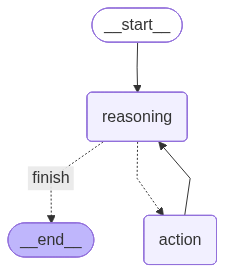

In [8]:
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Visualization unavailable in this environment:", e)
    print(app.get_graph().draw_mermaid())

## 8. Run the agent

Same question as Part 1: **"What's the weather and population of Bangalore?"**

Watch how the LLM autonomously decides what information to gather — it may follow the same weather → population order Part 1 hardcoded, or it may not. That unpredictability (within reason) is the whole point: the *decision* is now genuinely made by the model, not pre-written by us.

In [9]:
initial_state = {
    "messages": ["Question: What's the weather and population of Bangalore?"],
    "next_action": "reasoning",
    "iterations": 0,
}

print("🚀 STARTING LLM-POWERED REACT AGENT\n" + "=" * 50)

result = app.invoke(initial_state)

print("\n" + "=" * 50)
print("✅ DONE — full message trace:\n")
for m in result["messages"]:
    print(f"  • {m}")

🚀 STARTING LLM-POWERED REACT AGENT

🧠 REASON (iteration 0): Thought: I need to find the current weather in Bangalore. QUERY: "current weather in Bangalore"
⚡ ACT: searching for '"current weather in Bangalore"'
👀 OBSERVE: Bangalore weather: 24°C, partly cloudy, light breeze. Pleasant year-round climate due to elevation (~900m).

🧠 REASON (iteration 1): Thought: Now I need to find the current population of Bangalore. QUERY: "current population of Bangalore 2023"
⚡ ACT: searching for '"current population of Bangalore 2023"'
👀 OBSERVE: Bangalore population: approximately 13.6 million in the metropolitan area, making it India's 3rd most populous city.

🧠 REASON (iteration 2): Thought: I have gathered both the current weather and population of Bangalore. FINAL ANSWER: The current weather in Bangalore is 24°C, partly cloudy with a light breeze, and the population is approximately 13.6 million in the metropolitan area, making it India's 3rd most populous city.

✅ DONE — full message trace:

  

## 9. Try a question Part 1 could never handle

Part 1's hardcoded agent *always* asked about weather then population, no matter what you asked it — because `reason()` never actually read the question. Let's prove Part 2 doesn't have that limitation, using a Bangalore question with a completely different information need.

In [10]:
initial_state_2 = {
    "messages": ["Question: When is the best time to visit Bangalore, and how big is the city?"],
    "next_action": "reasoning",
    "iterations": 0,
}

print("🚀 RUNNING A DIFFERENT QUESTION\n" + "=" * 50)

result_2 = app.invoke(initial_state_2)

print("\n" + "=" * 50)
print("✅ DONE — full message trace:\n")
for m in result_2["messages"]:
    print(f"  • {m}")

🚀 RUNNING A DIFFERENT QUESTION

🧠 REASON (iteration 0): Thought: I need to find out the best time to visit Bangalore based on weather and tourism trends. QUERY: "best time to visit Bangalore"
⚡ ACT: searching for '"best time to visit Bangalore"'
👀 OBSERVE: Best time to visit Bangalore: October to February, when temperatures are coolest (15-28°C) and rainfall is lowest.

🧠 REASON (iteration 1): Thought: Now I need to find out the size of Bangalore in terms of area or population. QUERY: "Bangalore city size area population"
⚡ ACT: searching for '"Bangalore city size area population"'
👀 OBSERVE: Bangalore population: approximately 13.6 million in the metropolitan area, making it India's 3rd most populous city.

🧠 REASON (iteration 2): Thought: I have gathered the necessary information regarding the best time to visit Bangalore and its population size. Now I will compile the final answer. FINAL ANSWER: The best time to visit Bangalore is from October to February, when temperatures range fr

## 10. Part 1 vs. Part 2 — what actually changed?

| | Part 1 (hardcoded) | Part 2 (LLM-powered) |
|---|---|---|
| Graph shape | `reasoning → action → reasoning → ...` | **Identical** |
| State schema | `messages`, `next_action`, `iterations` | **Identical** |
| Router logic | Iteration cap + `next_action` | **Identical** |
| Action node | Parses a fixed-format query, calls mock tool | **Identical structure** — still parses a `QUERY:` string |
| Reasoning node | `if/elif` ladder keyed on iteration count | An LLM call, with the decision read from its own generated text |
| Can it generalize to new questions? | No — always weather then population | Yes — genuinely reads the question and decides what's relevant |

**The key insight from the original article, confirmed by what we just built:** LangGraph lets you separate your workflow's *structure* (the graph) from the *intelligence* that drives it (what's inside each node). The graph topology stayed exactly the same between Part 1 and Part 2 — we only swapped what's running inside the `reasoning` node, and that one swap transformed a rigid script into an adaptive agent.

**Where to go from here:**
- Replace `mock_search_tool` with a real search API (Tavily, Serper, etc.) — same pattern as the `search_flights` / `search_hotels` tools in the LangGraph travel-agent curriculum
- Add tool-selection logic with multiple distinct tools (not just one search function) — this is where `ToolNode` and `tools_condition` start to matter, since the LLM now has to *choose* which tool to call, not just *what query* to run
- Build a multi-agent system where multiple ReAct agents — each with their own graph like this one — collaborate on different sub-tasks